# Somatic Mutation (SOM) Analysis Pipeline



## Overview
This notebook performs a comprehensive statistical analysis of somatic mutations in head and neck cancer patients, stratified by HPV status. The analysis identifies significantly mutated genes using length-normalized mutation counts and dual statistical validation approaches (binomial and multinomial/empirical tests).

## Methodology

### 1. Data Preprocessing
- **Input Data**: TCGA somatic mutation data (MAF format) from the Nulton cohort
- **Mutation Filtering**: Only non-synonymous mutations are analyzed:
  - Frame_Shift_Del, Frame_Shift_Ins
  - In_Frame_Del, In_Frame_Ins
  - Missense_Mutation, Nonsense_Mutation
  - Nonstop_Mutation, Splice_Site, Translation_Start_Site
- **Gene Length Normalization**: CDS (coding sequence) lengths extracted from GENCODE v48 GTF annotation
- **Cohort Stratification**: HPV-positive vs HPV-negative patients

### 2. Mutation Counting and Normalization
For each gene, we calculate:
- **Raw mutation count**: Total number of mutations across all patients
- **Cohort frequency**: Number of patients with at least one mutation in the gene
- **Length-normalized count**: Mutation count divided by gene CDS length (bp)
- **Frequency percentage**: Percentage of patients with mutations in the gene
- **Mutation score**: Composite score combining amplitude (normalized count) and frequency

### 3. Statistical Significance Testing

#### A. Binomial Test (Parametric Approach)
Tests whether observed non-synonymous mutations in a gene exceed what would be expected by random chance, accounting for gene length and genome-wide mutation rate.

**Null Hypothesis**: Non-synonymous mutations are randomly distributed across the genome proportional to gene length.

**Denominator**: Uses **ALL mutations (synonymous + non-synonymous)** to establish the true genome-wide background mutation rate. This accounts for regional mutation rate variation and provides stable background estimation.

#### B. Empirical/Multinomial Test (Non-parametric Approach)
Generates a null distribution through Monte Carlo simulation to validate binomial test results.

**Approach**: Sample from multinomial distribution with gene-length-based probabilities, repeated 10,000 times.

**Denominator**: Uses **only non-synonymous mutations** to focus on the functionally relevant mutational landscape.

#### Dual-Denominator Rationale
The intentional use of different denominators provides **complementary validation** with distinct null hypotheses:
- **Binomial test**: Tests whether a gene has excess functional mutations given its overall mutational exposure (including synonymous mutations that reflect regional mutation processes)
- **Multinomial test**: Tests whether a gene is enriched for functional mutations compared to the empirical distribution of non-synonymous mutations across all genes

This dual approach dramatically reduces false positives by requiring genes to pass two independent statistical frameworks. Genes passing both tests demonstrate robust evidence of positive selection and biological significance, catching true driver genes while filtering out:
1. Hypermutable regions with many mutations but no functional enrichment
2. Random fluctuations in the functional mutation landscape
3. Sequencing artifacts or technical biases

### 4. Multiple Testing Correction
- **Method**: Benjamini-Hochberg False Discovery Rate (FDR) correction
- **Applied to**: Both binomial p-values and empirical p-values
- **Significance threshold**: Adjusted p-value < 0.05

### 5. Gene Filtering Criteria
Genes are selected based on multiple criteria:
- **HPV Positive cohort**:
  - Frequency percentage ≥ 5.0%
  - Mutation score ≥ 0.002
  - Adjusted p-value ≤ 0.05 (both binomial and empirical)
  - Normalized cohort frequency ≥ 0.001
  - Normalized count ≥ 0.001

- **HPV Negative cohort**:
  - Frequency percentage ≥ 0.01%
  - Adjusted p-value ≤ 0.05 (both binomial and empirical)
  - Normalized cohort frequency ≥ 0.0035
  - Normalized count ≥ 0.0035

## Output
- Raw gene mutation statistics for HPV+ and HPV- cohorts
- Filtered lists of significantly mutated genes passing all criteria
- Visualization of top mutated genes by frequency and mutation score

## Mathematical Formulas for Statistical Tests

### Binomial Test Formula

### Test Setup
For each gene $g$, we test whether the observed number of non-synonymous mutations exceeds random expectation given the genome-wide mutation rate.

**Parameters:**
- $k_g$ = observed number of **non-synonymous** mutations in gene $g$
- $N_{total}$ = total number of mutations in the cohort (**including both non-synonymous AND synonymous**)
- $L_g$ = CDS length of gene $g$ (in base pairs)
- $L_{total}$ = sum of CDS lengths of all protein-coding genes in the genome
- $p_g$ = probability that a random mutation occurs in gene $g$

**Critical Design Choice**: $N_{total}$ includes synonymous mutations to capture the true genome-wide background mutation rate. This accounts for regional mutation rate variation (e.g., hypermutable regions) and provides an unbiased baseline for testing functional mutation enrichment.

### Probability Calculation
The probability that a mutation occurs in gene $g$ is proportional to its length:

$$p_g = \frac{L_g}{L_{total}}$$

### Binomial Test Statistic
Under the null hypothesis (non-synonymous mutations randomly distributed), the number of non-synonymous mutations in gene $g$ follows a binomial distribution:

$$k_g \sim \text{Binomial}(N_{total}, p_g)$$

where $N_{total}$ includes **all mutations (synonymous + non-synonymous)**.

The probability of observing $k_g$ or more non-synonymous mutations in gene $g$ by chance is:

$$P\text{-value}_{\text{binomial}} = P(K \geq k_g) = \sum_{i=k_g}^{N_{total}} \binom{N_{total}}{i} p_g^i (1-p_g)^{N_{total}-i}$$

where $K \sim \text{Binomial}(N_{total}, p_g)$.

---

## Empirical/Multinomial Test Formula

### Test Setup
To validate the binomial test results, we generate a null distribution using Monte Carlo simulation with a multinomial distribution.

**Parameters:**
- $M$ = number of simulations (10,000 in this analysis)
- $G$ = total number of genes being analyzed
- $\mathbf{p} = (p_1, p_2, ..., p_G)$ = vector of gene probabilities where $p_g = \frac{L_g}{L_{total}}$
- $N_{nonsyn}$ = total number of **non-synonymous mutations only**

**Critical Design Choice**: $N_{nonsyn}$ includes ONLY non-synonymous mutations, focusing on the functionally relevant mutational landscape. This differs from the binomial test denominator intentionally, providing complementary validation.

### Multinomial Distribution
$$\mathbf{K}^{(m)} = (K_1^{(m)}, K_2^{(m)}, ..., K_G^{(m)}) \sim \text{Multinomial}(N_{nonsyn}, \mathbf{p})$$

where $N_{nonsyn}$ = total **non-synonymous mutations only**, and:

$$P(\mathbf{K} = (k_1, k_2, ..., k_G)) = \frac{N_{nonsyn}!}{k_1! k_2! \cdots k_G!} \prod_{g=1}^{G} p_g^{k_g}$$

and the constraint $\sum_{g=1}^{G} k_g = N_{nonsyn}$ is satisfied.

### Empirical P-value Calculation
For each gene $g$, after $M$ simulations, the empirical p-value is calculated with pseudocount adjustment:

$$P\text{-value}_{\text{empirical}}^{(g)} = \frac{1 + \sum_{m=1}^{M} \mathbb{1}(K_g^{(m)} \geq k_g^{\text{obs}})}{M + 1}$$

where:
- $k_g^{\text{obs}}$ = observed mutation count for gene $g$ in the real data
- $K_g^{(m)}$ = simulated mutation count for gene $g$ in simulation $m$
- $\mathbb{1}(\cdot)$ = indicator function (1 if condition is true, 0 otherwise)
- The "+1" in numerator and denominator prevents p-values of exactly 0, following standard practice for permutation-based inference

**Interpretation:** This represents the proportion of simulations where the simulated mutation count equals or exceeds the observed count, with pseudocount adjustment to avoid zero p-values. The minimum achievable p-value is $\frac{1}{M+1}$, which equals $\frac{1}{10001} \approx 0.0001$ for 10,000 simulations.

---

## Why Dual Testing with Different Denominators?

The intentional use of different denominators ($N_{total}$ for binomial, $N_{nonsyn}$ for multinomial) provides **complementary validation** that dramatically reduces false discoveries:

### What Each Test Captures:

**Binomial Test** (uses all mutations including synonymous):
- Tests: "Does this gene have more non-synonymous mutations than expected given the **regional mutation rate**?"
- Accounts for: Hypermutable regions, sequencing depth variation, DNA repair deficiencies
- Null hypothesis: Non-synonymous mutations proportional to gene length, given total mutational burden

**Multinomial Test** (uses only non-synonymous mutations):
- Tests: "Is this gene enriched for functional mutations compared to the **empirical distribution** of where non-synonymous mutations occur?"
- Accounts for: Actual patterns of driver vs passenger mutations across genes
- Null hypothesis: Non-synonymous mutations distributed according to observed functional mutation landscape

### Example Scenario:
- **Gene A** in a hypermutable region: 100 synonymous + 70 non-synonymous mutations
- **Gene B** in a stable region: 10 synonymous + 70 non-synonymous mutations

Using the same denominator for both tests would either:
1. Miss that Gene A's region has 2× higher background rate (if using only non-synonymous)
2. Create type I errors by not validating against functional mutation patterns (if using all mutations for both)

**Our dual approach**: Gene must show enrichment both relative to its regional mutation rate (binomial) AND relative to other genes' functional mutation patterns (multinomial), providing robust evidence of positive selection.

---

## Composite Mutation Score

The mutation score combines mutation burden (amplitude) with cohort prevalence (frequency):

$$\text{Mutation Score}_g = \text{Normalized Count}_g \times \text{Frequency Percentage}_g$$

where:
- $\text{Normalized Count}_g = \frac{k_g}{L_g}$ (mutations per base pair)
- $\text{Frequency Percentage}_g = \frac{n_g}{N_{\text{patients}}} \times 100$ 

This score is inspired by GISTIC's G-score approach, balancing amplitude and frequency of alterations.
This score is inspired by GISTIC's G-score approach, balancing amplitude and frequency of alterations.This score is inspired by GISTIC's G-score approach, balancing amplitude and frequency of alterations.
This score is inspired by GISTIC's G-score approach, balancing amplitude and frequency of alterations.

# Pipeline

In [109]:
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import math
from tqdm import tqdm

## Read in data

In [110]:
#somatic_mutation_file = 'Data/SOM/cohortMAF.2025-06-10.maf'
somatic_mutation_file = 'Data/TCGA/SOM/nulton_somatic_mutation_cohort.csv'
gtf_file = 'Data/TCGA/SOM/gencode.v48.annotation.gtf'

In [111]:
#somatic_mutation_download =pd.read_csv(somatic_mutation_file, sep='\t', comment = '#')
somatic_mutation_download = pd.read_csv(somatic_mutation_file)
somatic_mutation_download['Case ID'] = somatic_mutation_download['Tumor_Sample_Barcode'].str.split('-').str[0:3].str.join('-').tolist()

In [112]:
somatic_mutation_download['Score']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
86955   NaN
86956   NaN
86957   NaN
86958   NaN
86959   NaN
Name: Score, Length: 86960, dtype: float64

In [113]:
len(set(somatic_mutation_download['Case ID']))

499

In [114]:
len(set(somatic_mutation_download['Hugo_Symbol']))

16477

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'TTN'),
  Text(1, 0, 'TP53'),
  Text(2, 0, 'MUC16'),
  Text(3, 0, 'CSMD3'),
  Text(4, 0, 'FAT1'),
  Text(5, 0, 'SYNE1'),
  Text(6, 0, 'LRP1B'),
  Text(7, 0, 'CDKN2A'),
  Text(8, 0, 'DNAH5'),
  Text(9, 0, 'NOTCH1'),
  Text(10, 0, 'PCLO'),
  Text(11, 0, 'USH2A'),
  Text(12, 0, 'RYR2'),
  Text(13, 0, 'PIK3CA'),
  Text(14, 0, 'AHNAK'),
  Text(15, 0, 'KMT2D'),
  Text(16, 0, 'DST'),
  Text(17, 0, 'PLEC'),
  Text(18, 0, 'FLG'),
  Text(19, 0, 'NSD1')])

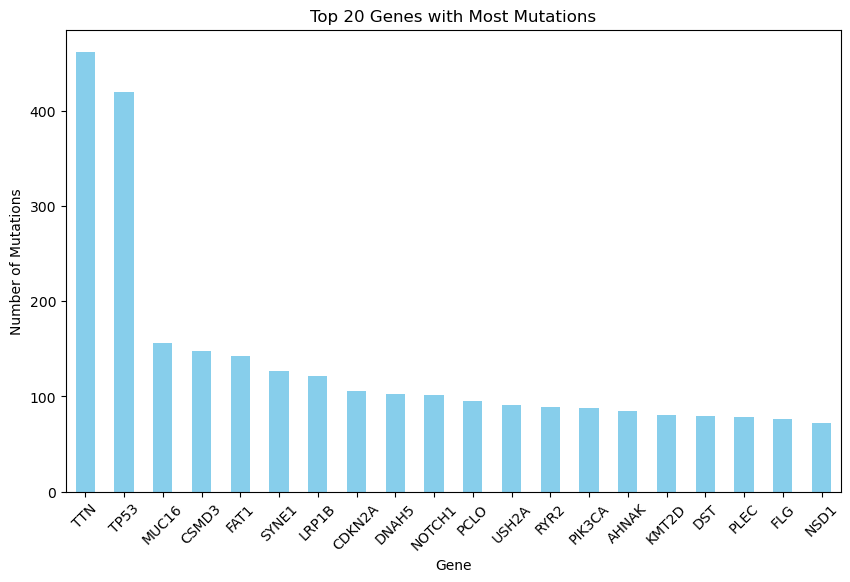

In [115]:
### calculate the number of mutations per gene, plot the top 20 genes with the most mutations
top_genes = somatic_mutation_download['Hugo_Symbol'].value_counts().head(20)
plt.figure(figsize=(10, 6))
top_genes.plot(kind='bar', color='skyblue')
plt.title('Top 20 Genes with Most Mutations')
plt.xlabel('Gene')
plt.ylabel('Number of Mutations')
plt.xticks(rotation=45)

Text(0, 0.5, 'Frequency')

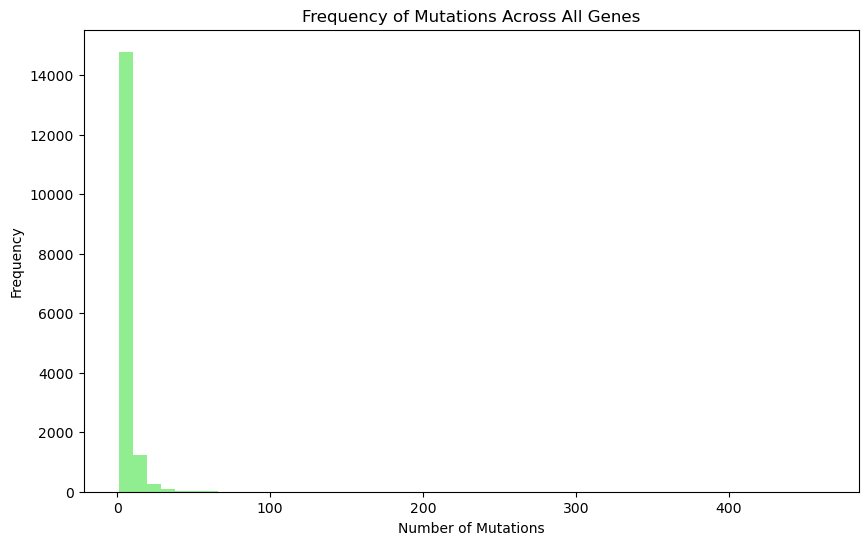

In [116]:
### plot the frequency of mutations across all genes
plt.figure(figsize=(10, 6))
somatic_mutation_download['Hugo_Symbol'].value_counts().plot(kind='hist', bins=50, color='lightgreen')
plt.title('Frequency of Mutations Across All Genes')
plt.xlabel('Number of Mutations')
plt.ylabel('Frequency')


In [117]:
print(len(set(somatic_mutation_download['tumor_bam_uuid'])))
print(len(set(somatic_mutation_download['normal_bam_uuid'])))

501
499


In [118]:
print(len(set(somatic_mutation_download['tumor_bam_uuid'])))
print(len(set(somatic_mutation_download['normal_bam_uuid'])))

501
499


### HPV

In [119]:
hpv_positive_patients = pd.read_csv('Results/HPV results/HPV positive patients.csv')
hpv_negative_patients = pd.read_csv('Results/HPV results/HPV negative patients.csv')

In [120]:
HPV_positive_df = pd.read_csv('Results/HPV results/HPV positive patients.csv')
HPV_positive_cases = [x for x in HPV_positive_df['TCGA CASE ID']]
HPV_positive_cases = list(set(HPV_positive_cases))
HPV_negative_df = pd.read_csv('Results/HPV results/HPV negative patients.csv')
HPV_negative_cases = [x for x in HPV_negative_df['TCGA CASE ID']]
HPV_negative_cases = list(set(HPV_negative_cases))

In [121]:
# print(len(set(HPV_negative_cases)))
temp_test = list(set((somatic_mutation_download[~somatic_mutation_download['Case ID'].isin(HPV_positive_cases)]['Case ID'].unique())))
for val in temp_test:
    if val not in HPV_negative_cases:
        print(val)

In [122]:
### overlap of hpv postive cases and somatic mutation cases
overlap_cases = set(HPV_positive_cases).intersection(set(somatic_mutation_download['Case ID']))
print("number of overlapping cases between HPV positive cases and somatic mutation cases: ", len(overlap_cases))

### overlap of hpv negative cases and somatic mutation cases
overlap_negative_cases = set(HPV_negative_cases).intersection(set(somatic_mutation_download['Case ID']))
print("number of overlapping cases between HPV negative cases and somatic mutation cases: ", len(overlap_negative_cases))

### those that are not hpv postive case ids in somatic mutation cases
non_hpv_positive_cases = list(set(somatic_mutation_download['Case ID']) - set(HPV_positive_cases))
print("number of non HPV positive cases in somatic mutation cases: ", len(non_hpv_positive_cases))

number of overlapping cases between HPV positive cases and somatic mutation cases:  66
number of overlapping cases between HPV negative cases and somatic mutation cases:  433
number of non HPV positive cases in somatic mutation cases:  433


In [123]:
len(set(somatic_mutation_download['Case ID']))

499

In [124]:
hpv_positive_patients

,Unnamed: 0,TCGA CASE ID
0,0,TCGA-HD-A634
1,1,TCGA-P3-A5QE
2,2,TCGA-BA-A4IH
3,3,TCGA-BB-7866
4,4,TCGA-DQ-7596
...,...,...
67,67,TCGA-CV-6939
68,68,TCGA-DQ-7591
69,69,TCGA-IQ-A61I
70,70,TCGA-HD-8314


In [125]:
def num_overlap(list1,list2):
    # Convert lists to sets
    set1 = set(list1)
    set2 = set(list2)

    # Find the intersection of the two sets
    overlap = set1.intersection(set2)

    # Get the number of overlapping values
    num_overlap = len(overlap)
    return num_overlap

In [126]:
num_overlap(hpv_positive_patients['TCGA CASE ID'], somatic_mutation_download['Case ID'])

66

## Mutation count

In [127]:
# Step 1: Parse GTF to extract gene metadata and CDS lengths
def parse_gtf(gtf_file):
    """
    Parse a GENECODE GTF file unzipped and extract gene-related metadata from CDS entries.
    Output a table with gene_id, gene_name, transcript_id, gene_type, tag, and total CDS length.
    CDS intervals across all transcripts are merged per gene to avoid double-counting shared exons.
    """
    # Store intervals per gene_id: {gene_id: {'meta': {...}, 'intervals': [(start, end), ...]}}
    gene_data = {}

    # Open and read the GTF file
    with open(gtf_file, 'r') as f:
        for line in tqdm(f, desc='Parsing GTF file'):
            ## Skip comment lines
            if line.startswith('#'):
                continue
            ## Split the line into fields
            ## GTF format: seqname, source, feature, start, end, score, strand, frame, attribute
            ## We are interested in the 'CDS' feature
            fields = line.strip().split('\t')
            ## Check if the feature is 'CDS'
            if fields[2] == 'CDS':
                ## extract gene_id and gene_name from attributes
                # attributes = fields[8].split('; ')
                # attr_dict = {
                #     attr.split(' ')[0]: attr.split(' ')[1].strip('"')
                #     for attr in attributes if ' ' in attr
                # }
                attr_dict = {}
                for field in fields[8].strip().split(';'):
                    field = field.strip()
                    if not field:
                        continue
                    key, value = field.split(' ', 1)
                    attr_dict[key] = value.strip('"')

                gene_id = attr_dict.get('gene_id')
                gene_name = attr_dict.get('gene_name')
                transcript_id = attr_dict.get('transcript_id')
                gene_type = attr_dict.get('gene_type')
                tag = attr_dict.get('tag')
                start = int(fields[3])
                end = int(fields[4])

                # Only gene_id, gene_name, and gene_type are required:
                # - gene_id: dictionary key
                # - gene_name: matched against Hugo symbols in somatic mutation data
                # - gene_type: used to filter for protein_coding genes
                # transcript_id and tag are stored as metadata only and are not required
                if not gene_id or not gene_name or not gene_type:
                    continue

                if gene_id not in gene_data:
                    gene_data[gene_id] = {
                        'gene_name': gene_name,
                        'transcript_id': transcript_id or '',
                        'gene_type': gene_type,
                        'tag': tag or '',
                        'intervals': []
                    }
                gene_data[gene_id]['intervals'].append((start, end))

    # Merge overlapping CDS intervals per gene and sum unique base pairs
    gene_cds_lengths = {}
    for gene_id, data in gene_data.items():
        intervals = sorted(data['intervals'])
        merged_length = 0
        cur_start, cur_end = intervals[0]
        for start, end in intervals[1:]:
            if start <= cur_end + 1:
                cur_end = max(cur_end, end)
            else:
                merged_length += cur_end - cur_start + 1
                cur_start, cur_end = start, end
        merged_length += cur_end - cur_start + 1

        gene_cds_lengths[gene_id] = {
            'gene_name': data['gene_name'],
            'transcript_id': data['transcript_id'],
            'gene_type': data['gene_type'],
            'tag': data['tag'],
            'cds_length': merged_length
        }

    # Convert to DataFrame
    gene_cds_df = pd.DataFrame.from_dict(gene_cds_lengths, orient='index').reset_index()
    gene_cds_df.columns = ['gene_id', 'gene_name', 'transcript_id', 'gene_type', 'tag', 'cds_length']
    return gene_cds_df


In [128]:
gene_lengths_File = parse_gtf(gtf_file)

Parsing GTF file: 4107087it [00:06, 603850.28it/s]


In [129]:
gene_lengths_File

,gene_id,gene_name,transcript_id,gene_type,tag,cds_length
0,ENSG00000186092.7,OR4F5,ENST00000641515.2,protein_coding,CCDS,978
1,ENSG00000284733.2,OR4F29,ENST00000426406.4,protein_coding,CCDS,936
2,ENSG00000284662.2,OR4F16,ENST00000332831.5,protein_coding,CCDS,936
3,ENSG00000187634.13,SAMD11,ENST00000616016.5,protein_coding,CCDS,2682
4,ENSG00000188976.11,NOC2L,ENST00000327044.7,protein_coding,CCDS,2247
...,...,...,...,...,...,...
20503,ENSG00000212907.2,MT-ND4L,ENST00000361335.1,protein_coding,appris_principal_1,294
20504,ENSG00000198886.2,MT-ND4,ENST00000361381.2,protein_coding,appris_principal_1,1378
20505,ENSG00000198786.2,MT-ND5,ENST00000361567.2,protein_coding,appris_principal_1,1809
20506,ENSG00000198695.2,MT-ND6,ENST00000361681.2,protein_coding,appris_principal_1,525


In [130]:
#gene_lengths with duplicate gene names
duplicate_gene_names = gene_lengths_File[gene_lengths_File.duplicated(subset=['gene_name'], keep=False)]['gene_name'].unique()
print("Duplicate gene names:", duplicate_gene_names)

Duplicate gene names: ['C4orf36' 'HERC3' 'PDE8B' 'MATR3' 'POLR2J3' 'PINX1' 'KYAT1' 'DUSP13B'
 'FAM174C' 'PDE4C' 'PLCXD1' 'GTPBP6' 'PPP2R3B' 'SHOX' 'CRLF2' 'CSF2RA'
 'IL3RA' 'SLC25A6' 'ASMTL' 'P2RY8' 'AKAP17A' 'ASMT' 'DHRSX' 'ZBED1' 'CD99'
 'VAMP7' 'IL9R' 'WASH6P']


In [131]:
gene_lengths_File['gene_type'].unique()

array(['protein_coding', 'IG_V_gene', 'IG_C_gene', 'IG_J_gene',
       'TR_C_gene', 'TR_J_gene', 'TR_V_gene', 'TR_D_gene', 'IG_D_gene'],
      dtype=object)

In [132]:
gene_lengths_File[gene_lengths_File['gene_type'] == 'protein_coding']['cds_length'].sum()

36528920

In [133]:
gene_lengths_File['cds_length'].sum()

36639934

In [134]:
gene_lengths_File['gene_name'].nunique()

20480

In [135]:
som_genes = somatic_mutation_download['Hugo_Symbol'].unique()
print("number of unique genes in somatic mutation data: ", len(som_genes))

gene_lengths_File_temp = gene_lengths_File[gene_lengths_File['gene_type'] == 'protein_coding']
number_genes_in_lengths = gene_lengths_File_temp[gene_lengths_File_temp['gene_name'].isin(som_genes)]['gene_name'].nunique()
print("number of genes in gene lengths file that are also in somatic mutation data: ", number_genes_in_lengths)

## average length of genes in gene lengths file that are also in somatic mutation data
average_length_genes_in_som = gene_lengths_File_temp[gene_lengths_File_temp['gene_name'].isin(som_genes)]['cds_length'].mean()
print("average length of genes in gene lengths file that are also in somatic mutation data: ", average_length_genes_in_som)

number of unique genes in somatic mutation data:  16477
number of genes in gene lengths file that are also in somatic mutation data:  15806
average length of genes in gene lengths file that are also in somatic mutation data:  2021.7348034879312


In [136]:
somatic_mutation_file = 'Data/TCGA/SOM/nulton_somatic_mutation_cohort.csv' 
# somatic_mutation_file = 'Data/TCGA/SOM/cohortMAF.2025-11-12.maf'
#somatic_mutation = pd.read_csv(somatic_mutation_file, sep='\t', comment='#')
somatic_mutation = pd.read_csv(somatic_mutation_file)
somatic_mutation['Case ID'] = somatic_mutation['Tumor_Sample_Barcode'].str.split('-').str[0:3].str.join('-').tolist()
# Ensure 'Case ID' is in the DataFrame
#print(somatic_mutation['Case ID'])
# somatic_mutation = somatic_mutation[somatic_mutation['Case ID'].isin(cases)]
case_column = 'Case ID'

non_synon_synon_mutations = len(set(somatic_mutation['Hugo_Symbol']))
print("Total number of somatic mutations before filtering: ", non_synon_synon_mutations)
gene_lengths_df = gene_lengths_File
gene_lengths_df = gene_lengths_df[gene_lengths_df['gene_type'] == 'protein_coding']
# Convert gene lengths DataFrame to a dictionary for quick access
gene_lengths = gene_lengths_df.set_index('gene_name')['cds_length'].to_dict()

mutation_gene_df = somatic_mutation[['Hugo_Symbol', 'Case ID']].copy()

# This ensures we only analyze genes with known protein-coding sequences
genes_before = len(mutation_gene_df['Hugo_Symbol'].unique())
mutation_gene_df = mutation_gene_df[mutation_gene_df['Hugo_Symbol'].isin(gene_lengths.keys())]
genes_after = len(mutation_gene_df['Hugo_Symbol'].unique())
print(f"Filtered out {genes_before - genes_after} genes not in reference genome (keeping {genes_after} genes)")


Total number of somatic mutations before filtering:  16477
Filtered out 671 genes not in reference genome (keeping 15806 genes)


In [ ]:
# Step 2: Analyze somatic mutations using gene metadata
def somatic_mutation_gene_count(somatic_mutation_file, cases, gene_lengths_df):
    """
    Count and normalize somatic mutations per gene, calculate cohort frequency, and perform significance testing.
    """
    cases = list(set(cases))  # Ensure cases is a list of unique case IDs
    #somatic_mutation = pd.read_csv(somatic_mutation_file, sep='\t', comment='#')
    somatic_mutation = pd.read_csv(somatic_mutation_file)
    somatic_mutation['Case ID'] = somatic_mutation['Tumor_Sample_Barcode'].str.split('-').str[0:3].str.join('-').tolist()
    # Ensure 'Case ID' is in the DataFrame
    #print(somatic_mutation['Case ID'])
    # Filter to the HPV-stratified cohort (HPV+ or HPV- case list passed in as `cases`)
    somatic_mutation = somatic_mutation[somatic_mutation['Case ID'].isin(cases)]
    case_column = 'Case ID'

    # Background mutation count: total mutations (synonymous + non-synonymous)
    # Used as the binomial trial denominator — cohort-specific, not full-dataset.
    non_synon_synon_mutations = len(somatic_mutation)
    print("Total number of somatic mutations before filtering: ", non_synon_synon_mutations)
    # Filter for non-synonymous mutations
    non_synonymous_types = ['Frame_Shift_Del', 'Frame_Shift_Ins',
                             'In_Frame_Del', 'In_Frame_Ins',
                            'Missense_Mutation', 'Nonsense_Mutation', 
                            'Nonstop_Mutation', 'Splice_Site', 'Translation_Start_Site']
    
    # Filter the DataFrame for non-synonymous mutations
    somatic_mutation = somatic_mutation[
        somatic_mutation['Variant_Classification'].isin(non_synonymous_types)
    ]
    print("Total number of somatic mutations after filtering for non-synonymous: ", len(somatic_mutation))
    # Load gene lengths from the provided DataFrame
    ### filter for protein coding genes only
    ### this is crucial as TCGA does WXS only uses protein coding genes for mutation analysis
    gene_lengths_df = gene_lengths_df[gene_lengths_df['gene_type'] == 'protein_coding']
    # Convert gene lengths DataFrame to a dictionary for quick access
    gene_lengths = gene_lengths_df.set_index('gene_name')['cds_length'].to_dict()

    # Count mutations per gene
    mutation_dict = {}
    for mut in tqdm(somatic_mutation['Hugo_Symbol'], desc='Counting mutations'):
        mutation_dict[mut] = mutation_dict.get(mut, 0) + 1
    # Create a DataFrame from the mutation dictionary
    mutation_gene_df = pd.DataFrame(list(mutation_dict.items()), columns=['Gene', 'Count'])

    ### calculate mutation frequency by case id
    cohort_frequency = somatic_mutation.groupby('Hugo_Symbol')[case_column].nunique().reset_index()
    cohort_frequency.columns = ['Gene', 'Cohort_Frequency']
    # Merge mutation counts with cohort frequency
    ### now both mutation count in general and frequency by case id are available
    mutation_gene_df = mutation_gene_df.merge(cohort_frequency, on='Gene')

    # Filter out genes not in the reference genome (gene_lengths dictionary)
    # This ensures we only analyze genes with known protein-coding sequences
    genes_before = len(mutation_gene_df)
    mutation_gene_df = mutation_gene_df[mutation_gene_df['Gene'].isin(gene_lengths.keys())]
    genes_after = len(mutation_gene_df)
    print(f"Filtered out {genes_before - genes_after} genes not in reference genome (keeping {genes_after} genes)")

    # Normalize mutation counts by gene length
    # Ensure gene lengths are available for normalization
    if not gene_lengths:
        raise ValueError("Gene lengths data is empty or not provided.")
    
    # Normalize mutation counts by gene length
    # This assumes gene_lengths is a dictionary with gene names as keys and lengths as values
    mutation_gene_df['Normalized_Count'] = mutation_gene_df.apply(
        lambda row: row['Count'] / gene_lengths.get(row['Gene'], 2021), axis=1
    ) #default to average gene length if not found

    ### calculate a normalized mutation frequency by case id
    mutation_gene_df['Normalized_Cohort_Frequency'] = mutation_gene_df.apply(
        lambda row: row['Cohort_Frequency'] / gene_lengths.get(row['Gene'], 2021), axis=1
    ) # Default to average gene length if not found

    ### Perform binomial test for significance
    # Calculate total mutations in the dataset
    total_mutations = somatic_mutation.shape[0]
    # Get total number of patients in the cohort
    total_patients = len(cases)
    # total_genome_length: sum of all protein-coding CDS base pairs from GENCODE annotation.
    # Intentionally uses the whole protein-coding genome as the mutational target space,
    # consistent with TCGA WXS scope and standard tools (e.g., MutSig).
    # p_gene = gene_length / total_genome_length represents each gene's proportional
    # share of the total targetable genome.
    total_genome_length = sum(gene_lengths.values())
    # Binomial test to calculate p-values for each gene
    # Tests: out of N total mutations, how many mutations occur in this gene?
    # Uses length-based probability: p = gene_length / total_genome_length
    # This represents the proportion of mutational target space occupied by each gene
    # Expected mutations in gene = p_gene * total_mutations
    binom_p_vals = []
    for _, row in mutation_gene_df.iterrows():
        gene = row['Gene']
        observed_mutations = row['Count']  # Number of mutations in this gene
        gene_length = gene_lengths.get(gene, 2021) # Default to average gene length if not found
        # hypothesized prob of success = gene length / total genome length
        p_gene = gene_length / total_genome_length
        ### binomial test using non-synonymous + synonymous mutations as total mutations
        ### this provides a more accurate background mutation rate for the test
        ### observed_mutations = row['Count']  # Number of mutations in this gene
        ### p_gene = gene_length / total_genome_length(protein coding genes only) this accounts for the fact 
        # that we are only using protein coding genes for mutation analysis, and TCGA does WXS only uses protein coding genes for mutation analysis
        p_val = binomtest(observed_mutations, non_synon_synon_mutations, p_gene, alternative='greater').pvalue
        binom_p_vals.append(p_val)
    
    mutation_gene_df['P_Value'] = binom_p_vals
    # print(binom_p_vals)
    ### Adjust p-values for multiple testing using Benjamini-Hochberg method
    mutation_gene_df['Adjusted_P_Value'] = multipletests(mutation_gene_df['P_Value'], method='fdr_bh')[1]
    ### column for significance
    mutation_gene_df['Significant'] = mutation_gene_df['Adjusted_P_Value'] < 0.05
    
    # Generate a null distribution of mutation counts based on gene probabilities
    # This uses a multinomial distribution where the total number of mutations is the sum of all mutation counts
    # and the probabilities are based on gene lengths
    np.random.seed(42)  # For reproducibility
    num_simulations = 10000  # Number of simulations for empirical p-value calculation
    # Generate a null distribution of mutation counts based on gene probabilities
    ### a multinomial distribution is used because it allows for the simulation of counts across multiple categories (genes) based on specified probabilities
    ### the inputs for the multinomial distribution are the total number of mutations and the probabilities for each gene, 
    ### this allows for the generation of a distribution of mutation counts that reflects the expected distribution of mutations across genes based on their lengths
    ### total_mutations = somatic_mutation.shape[0] # total number of mutations in the dataset
    ### gene_probs = gene_lengths_array / gene_lengths_array.sum()  # Calculate probabilities based on gene lengths
    ### num_simulations = 10000  # Number of simulations for empirical p-value calculation
    ### null distribution will now be a 2D array where each row represents a simulated count of mutations across genes 
    ### and each column represents a gene
    ### to call the counts for a specific gene, you can index into the array using the gene's index
    ### i.e. null_distribution[:, gene_index] will give you the simulated counts for the gene at gene_index
    gene_names = mutation_gene_df['Gene'].tolist()
    gene_lengths_array = np.array([gene_lengths.get(gene, 2021) for gene in gene_names])  # Get gene lengths for normalization
    gene_probs = gene_lengths_array /  sum(gene_lengths.values())  # Calculate probabilities based on gene lengths
    ### add a sink for the remaining prob
    gene_probs = np.append(gene_probs, 1 - gene_probs.sum())
    null_distribution = np.random.multinomial(total_mutations, gene_probs, size=num_simulations) 
    
    empirical_p_values = []
    for gene in gene_names:
        observed_count = mutation_dict.get(gene, 0)
        # Calculate the empirical p-value for each gene
        # The empirical p-value is the proportion of simulated counts that are greater than or equal to the observed count
        if gene in gene_lengths:
            gene_index = gene_names.index(gene)
            simulated_counts = null_distribution[:, gene_index]
            empirical_p_value = (np.sum(simulated_counts >= observed_count) + 1) / (len(simulated_counts) + 1)
        else:
            empirical_p_value = 1.0  # If the gene is not in the gene lengths, set empirical p-value to 1.
        empirical_p_values.append(empirical_p_value)

    # Add empirical p-values to the DataFrame
    mutation_gene_df['Empirical_P_Value'] = empirical_p_values
    ### multiple testing correction for empirical p-values
    mutation_gene_df['Adjusted_Empirical_P_Value'] = multipletests(mutation_gene_df['Empirical_P_Value'], method='fdr_bh')[1]

    ### Calculate frequency percentage (percentage of patients with mutation in gene)
    mutation_gene_df['frequency_percentage'] = (mutation_gene_df['Cohort_Frequency'] / total_patients) * 100
    
    ### Calculate a composite score combining amplitude and frequency (similar to GISTIC G-score)
    ### Amplitude: Normalized_Count (mutation burden per gene, normalized by gene length)
    ### Frequency: frequency_percentage (proportion of patients with mutation in gene)
    ### This balances mutation burden (amplitude) with cohort prevalence (frequency)
    mutation_gene_df['mutation_score'] = mutation_gene_df['Normalized_Count'] * mutation_gene_df['frequency_percentage']

    mutation_gene_df = mutation_gene_df.sort_values(by=['Adjusted_P_Value', 'Cohort_Frequency'], ascending=[True, False])

# Step 3: Run the full pipeline
    return mutation_gene_df

# Step 3: Run the full pipeline
def run_mutation_analysis_pipeline(mutation_file, gene_length_file, case_list):
    gene_lengths_df = parse_gtf(gene_length_file)
    results = somatic_mutation_gene_count(mutation_file, case_list, gene_lengths_df)
    return results

# Step 4: Visualize results
def visualize_results(results):
    top_genes_raw = results.nlargest(20, 'Count')
    plt.figure(figsize=(10, 6))
    plt.barh(top_genes_raw['Gene'], top_genes_raw['Count'], color='skyblue')
    plt.xlabel('Raw Mutation Count')
    plt.ylabel('Gene')
    plt.title('Top 20 Genes by Raw Mutation Count')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('top_genes_raw.png')
    plt.show()

    top_genes_normalized = results.nlargest(20, 'Normalized_Count')
    plt.figure(figsize=(10, 6))
    plt.barh(top_genes_normalized['Gene'], top_genes_normalized['Normalized_Count'], color='salmon')
    plt.xlabel('Normalized Mutation Count')

    # plt.show()   
    # plt.savefig('top_genes_normalized.png')    
    # plt.tight_layout()    
    # plt.gca().invert_yaxis()    
    # plt.title('Top 20 Genes by Normalized Mutation Count')    
    # plt.ylabel('Gene')    

    plt.show()

In [138]:
# Visualization and filtering functions for SOM analysis (similar to CNV 02.2 approach)
def plot_score_distribution(df):
    """
    Plot distribution of key metrics for mutation significance analysis.
    Similar to CNV analysis visualization approach.
    """
    scores = ['frequency_percentage', 'mutation_score', 'Normalized_Cohort_Frequency', 'Normalized_Count']
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, score in enumerate(scores):
        ax = axes[i]
        ax.hist(df[score].dropna(), bins=50, edgecolor='black', alpha=0.7)
        ax.set_xlabel(score, fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title(f'Distribution of {score}', fontsize=14)
        ax.axvline(df[score].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df[score].mean():.4f}')
        #ax.axvline(df[score].quantile(0.95), color='green', linestyle='dashed', linewidth=2, label=f'95th percentile: {df[score].quantile(0.95):.4f}')
        if score in ['Adjusted_P_Value', 'Adjusted_Empirical_P_Value']:
            ax.axvline(0.05, color='purple', linestyle='dashed', linewidth=1, label='Significance Threshold: 0.05')
        ax.legend()
        ax.set_yscale('log')
    
    # Hide the last subplot if we have an odd number
    if len(scores) < len(axes):
        axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_score_distribution_with_cutoff(df, cutoffs):
    """
    Plot distribution with custom cutoff lines.
    """
    scores = ['frequency_percentage', 'mutation_score', 'Normalized_Cohort_Frequency', 'Normalized_Count']
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, score in enumerate(scores):
        ax = axes[i]
        ax.hist(df[score].dropna(), bins=50, edgecolor='black', alpha=0.7)
        ax.set_xlabel(score, fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title(f'Distribution of {score}', fontsize=14)
        
        if score in cutoffs:
            ax.axvline(cutoffs[score], color='red', linestyle='dashed', linewidth=2, label=f'Cutoff: {cutoffs[score]}')
        
        if score in ['Adjusted_P_Value', 'Adjusted_Empirical_P_Value']:
            ax.axvline(0.05, color='purple', linestyle='dashed', linewidth=1, label='Significance: 0.05')
        ax.legend()
        ax.set_yscale('log')
    
    if len(scores) < len(axes):
        axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_top_genes(df, title='Top Genes'):
    """
    Visualize top genes by multiple metrics.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 20 by frequency_percentage
    top_freq = df.nlargest(20, 'frequency_percentage')
    axes[0].barh(top_freq['Gene'], top_freq['frequency_percentage'], color='steelblue')
    axes[0].set_xlabel('Frequency Percentage (%)', fontsize=12)
    axes[0].set_ylabel('Gene', fontsize=12)
    axes[0].set_title(f'{title} - Top 20 by Frequency %', fontsize=14)
    axes[0].invert_yaxis()
    
    # Top 20 by mutation_score
    top_score = df.nlargest(20, 'mutation_score')
    axes[1].barh(top_score['Gene'], top_score['mutation_score'], color='coral')
    axes[1].set_xlabel('Mutation Score', fontsize=12)
    axes[1].set_ylabel('Gene', fontsize=12)
    axes[1].set_title(f'{title} - Top 20 by Mutation Score', fontsize=14)
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

def filter_top_genes(df, cutoffs):
    """
    Filter genes based on multiple cutoff criteria.
    Similar to CNV 02.2 filtering approach.
    
    Parameters:
    -----------
    df : DataFrame
        Results from mutation analysis
    cutoffs : dict
        Dictionary with cutoff values, e.g.:
        {
            'frequency_percentage': 10.0,
            'mutation_score': 0.05,
            'Adjusted_P_Value': 0.05,
            'Adjusted_Empirical_P_Value': 0.05,
            'Cohort_Frequency': 5
        }
    
    Returns:
    --------
    DataFrame
        Filtered genes meeting all criteria
    """
    # Remove rows with zero values in key metrics
    filtered_df = df[(df['frequency_percentage'] != 0) & (df['mutation_score'] != 0)].copy()
    
    # Apply cutoffs
    for metric, threshold in cutoffs.items():
        if metric in ['Adjusted_P_Value', 'Adjusted_Empirical_P_Value']:
            # For p-values, filter for values <= threshold
            filtered_df = filtered_df[filtered_df[metric] <= threshold]
        else:
            # For other metrics, filter for values >= threshold
            filtered_df = filtered_df[filtered_df[metric] >= threshold]
    
    print(f"Genes passing all cutoffs: {len(filtered_df)} out of {len(df)} total genes")
    
    return filtered_df

In [139]:
test_list = [x[0:12] for x in list(set(somatic_mutation_download['Tumor_Sample_Barcode']))]
print(num_overlap(test_list,  list(set(HPV_positive_df['TCGA CASE ID'])) ))
print(num_overlap(test_list,  list(set(HPV_negative_df['TCGA CASE ID'])) ))

66
433


In [140]:
HPV_positive_idx= []
HPV_negative_idx = []
for i,val in tqdm(enumerate(list(somatic_mutation_download['Tumor_Sample_Barcode']))):
    test_val = val[0:12]
    if test_val in HPV_positive_cases:
        HPV_positive_idx.append(i)
    elif test_val in HPV_negative_cases:
        HPV_negative_idx.append(i)

86960it [00:00, 429769.88it/s]


In [141]:
print(len(HPV_positive_idx))
print(len(HPV_negative_idx))
print(len(HPV_positive_idx)+ len(HPV_negative_idx))

8372
78588
86960


In [142]:
# somatic_mutation_file = 'Data/SOM/cohortMAF.2025-06-10.maf'
# gtf_file = 'Data/SOM/gencode.v48.annotation.gtf'

### HPV+

In [143]:
hpv_positive_cases = list(hpv_positive_patients['TCGA CASE ID'])
print(len(set(hpv_positive_cases)))

72


In [144]:
len(hpv_positive_cases)

72

In [145]:
somatic_mutation_download['Case ID']

0        TCGA-CN-4737
1        TCGA-CN-4737
2        TCGA-CN-4737
3        TCGA-CN-4737
4        TCGA-CN-4737
             ...     
86955    TCGA-MZ-A6I9
86956    TCGA-MZ-A6I9
86957    TCGA-MZ-A6I9
86958    TCGA-MZ-A6I9
86959    TCGA-MZ-A6I9
Name: Case ID, Length: 86960, dtype: object

In [146]:
hpv_positive_case_somatic = somatic_mutation_download[somatic_mutation_download['Case ID'].isin(hpv_positive_cases)]

In [147]:
len(set(hpv_positive_case_somatic['Case ID']))

66

In [148]:
len(set(hpv_positive_case_somatic['Hugo_Symbol']))

5728

In [149]:
hpv_positive_case_somatic

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,COSMIC,hotspot,tumor_bam_uuid,normal_bam_uuid,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers,Case ID
181,ASAP3,55616,BI,GRCh38,chr1,23433236,23433236,+,Missense_Mutation,SNP,...,NaN,N,cd67cfda-e8da-44b0-a3b8-42a798f5a746,ccea9688-d171-4f11-a8a8-66df2314e451,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-BB-4225
182,ASAP3,55616,BI,GRCh38,chr1,23437262,23437262,+,Missense_Mutation,SNP,...,NaN,N,cd67cfda-e8da-44b0-a3b8-42a798f5a746,ccea9688-d171-4f11-a8a8-66df2314e451,Unknown,NaN,NaN,NaN,muse;varscan2,TCGA-BB-4225
183,HECTD3,79654,BI,GRCh38,chr1,45010108,45010108,+,Missense_Mutation,SNP,...,COSM910138,N,cd67cfda-e8da-44b0-a3b8-42a798f5a746,ccea9688-d171-4f11-a8a8-66df2314e451,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-BB-4225
184,CCDC17,149483,BI,GRCh38,chr1,45622294,45622294,+,Missense_Mutation,SNP,...,NaN,N,cd67cfda-e8da-44b0-a3b8-42a798f5a746,ccea9688-d171-4f11-a8a8-66df2314e451,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-BB-4225
185,RBM15,64783,BI,GRCh38,chr1,110339507,110339507,+,Silent,SNP,...,NaN,N,cd67cfda-e8da-44b0-a3b8-42a798f5a746,ccea9688-d171-4f11-a8a8-66df2314e451,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-BB-4225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86955,C19orf47,126526,BI,GRCh38,chr19,40322053,40322053,+,Missense_Mutation,SNP,...,NaN,N,45ec8d82-e4e6-4eb9-b3a0-6a16d929fcc9,3761a520-1166-4383-97af-2c3244c7f58f,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-MZ-A6I9
86956,ZNF155,7711,BI,GRCh38,chr19,43996817,43996825,+,In_Frame_Del,DEL,...,NaN,N,45ec8d82-e4e6-4eb9-b3a0-6a16d929fcc9,3761a520-1166-4383-97af-2c3244c7f58f,Unknown,NaN,NaN,NaN,mutect2;pindel;varscan2,TCGA-MZ-A6I9
86957,ZNF135,7694,BI,GRCh38,chr19,58068051,58068051,+,Nonsense_Mutation,SNP,...,NaN,N,45ec8d82-e4e6-4eb9-b3a0-6a16d929fcc9,3761a520-1166-4383-97af-2c3244c7f58f,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-MZ-A6I9
86958,FOXR2,139628,BI,GRCh38,chrX,55623864,55623864,+,Silent,SNP,...,NaN,N,45ec8d82-e4e6-4eb9-b3a0-6a16d929fcc9,3761a520-1166-4383-97af-2c3244c7f58f,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,TCGA-MZ-A6I9


In [150]:
hpv_positive_case_somatic['Hugo_Symbol'].nunique()

5728

In [151]:
hpv_pos_results = run_mutation_analysis_pipeline(somatic_mutation_file, gtf_file, hpv_positive_cases)

Parsing GTF file: 4107087it [00:06, 613029.45it/s]


Total number of somatic mutations before filtering:  8372
Total number of somatic mutations after filtering for non-synonymous:  6077


Counting mutations: 100%|██████████| 6077/6077 [00:00<00:00, 4743864.77it/s]

Filtered out 65 genes not in reference genome (keeping 4388 genes)


In [152]:
hpv_pos_results

,Gene,Count,Cohort_Frequency,Normalized_Count,Normalized_Cohort_Frequency,P_Value,Adjusted_P_Value,Significant,Empirical_P_Value,Adjusted_Empirical_P_Value,frequency_percentage,mutation_score
78,PIK3CA,18,17,0.005473,0.005169,4.738394e-19,2.079207e-15,True,0.000100,0.036563,23.611111,0.129219
918,ZNF750,11,8,0.005071,0.003688,7.324983e-12,1.607101e-08,True,0.000100,0.036563,11.111111,0.056350
998,CYLD,8,8,0.002677,0.002677,6.578872e-07,9.622697e-04,True,0.000100,0.036563,11.111111,0.029749
2311,EP300,9,9,0.001243,0.001243,6.021135e-05,4.723959e-02,True,0.000100,0.036563,12.500000,0.015534
690,CCDC191,6,6,0.002083,0.002083,6.589348e-05,4.723959e-02,True,0.000100,0.036563,8.333333,0.017355
...,...,...,...,...,...,...,...,...,...,...,...,...
708,MUC4,1,1,0.000062,0.000062,9.760135e-01,9.769040e-01,False,0.931007,0.931856,1.388889,0.000085
3049,MDN1,1,1,0.000060,0.000060,9.787807e-01,9.794504e-01,False,0.938606,0.939034,1.388889,0.000083
420,HMCN1,1,1,0.000059,0.000059,9.793430e-01,9.797896e-01,False,0.935506,0.936146,1.388889,0.000082
59,OBSCN,2,2,0.000070,0.000070,9.895552e-01,9.897807e-01,False,0.953305,0.953522,2.777778,0.000194


In [153]:
hpv_pos_results.to_csv('Results/SOM results/HPV positive raw genes.csv', index=False)

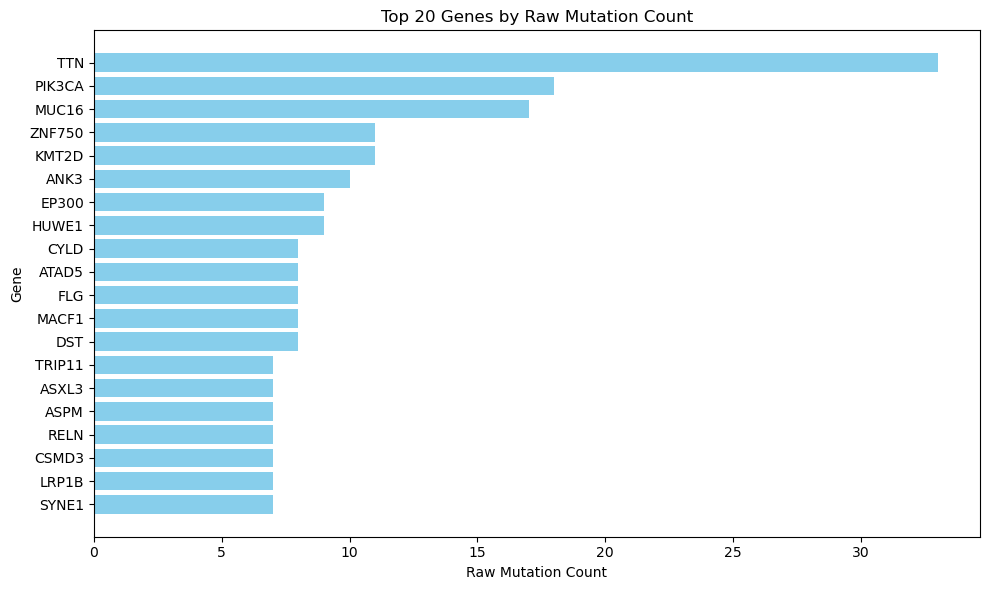

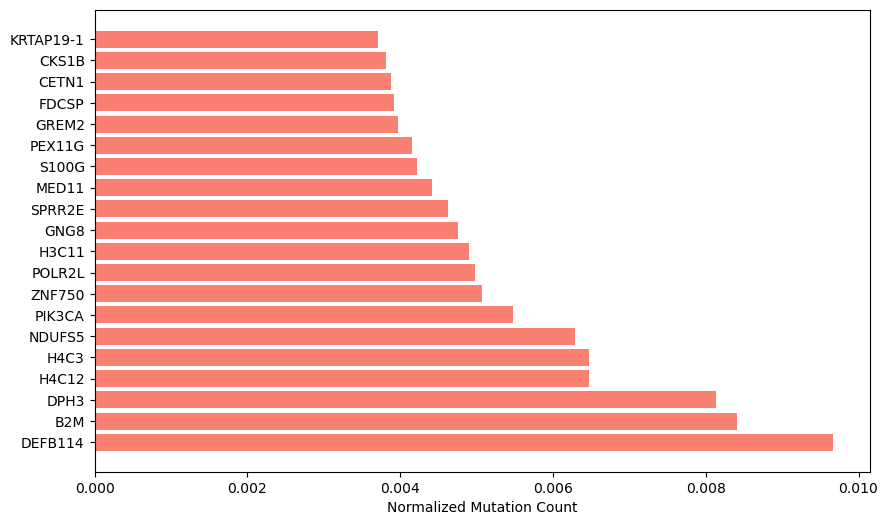

In [154]:
visualize_results(hpv_pos_results)

#### HPV Positive - Exploratory Analysis for Cutoff Determination

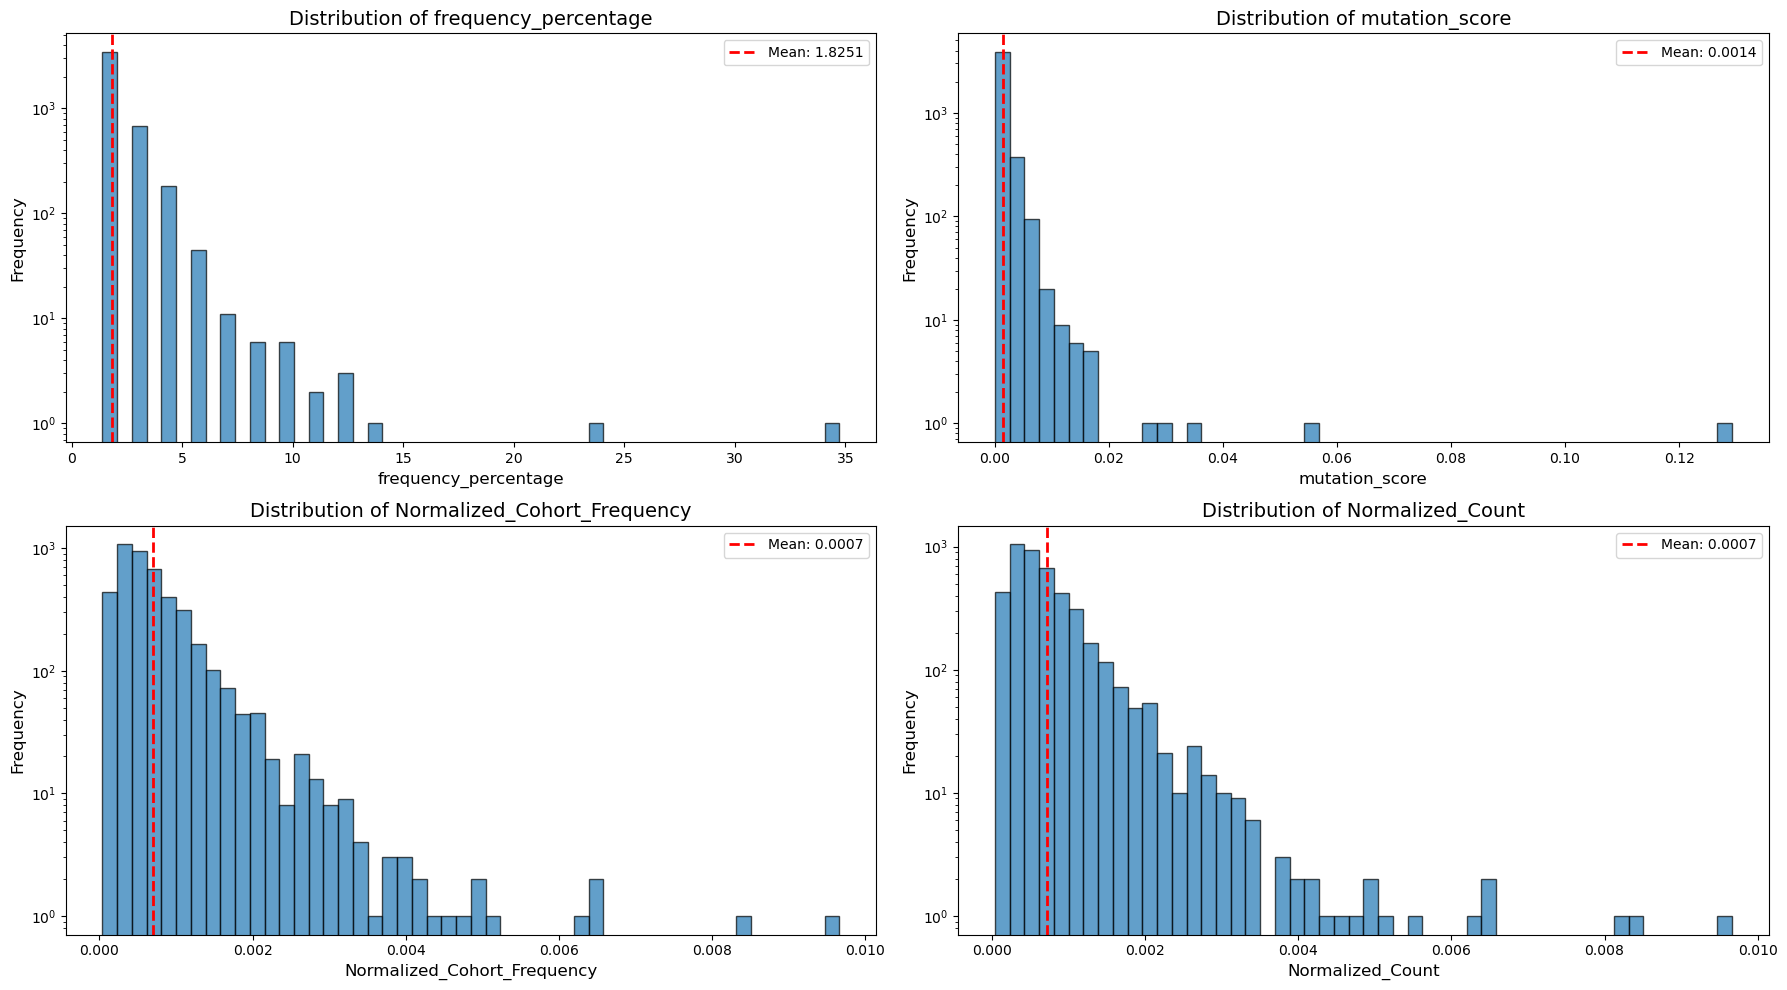

In [155]:
# Visualize score distributions to determine appropriate cutoffs
plot_score_distribution(hpv_pos_results)

In [156]:
hpv_pos_cutoffs = {
    'frequency_percentage': 5.0,
    'mutation_score': .002,
    'Adjusted_P_Value': 0.05,
    'Adjusted_Empirical_P_Value': 0.05,
    'Normalized_Cohort_Frequency': .001,
    'Normalized_Count': .001
}

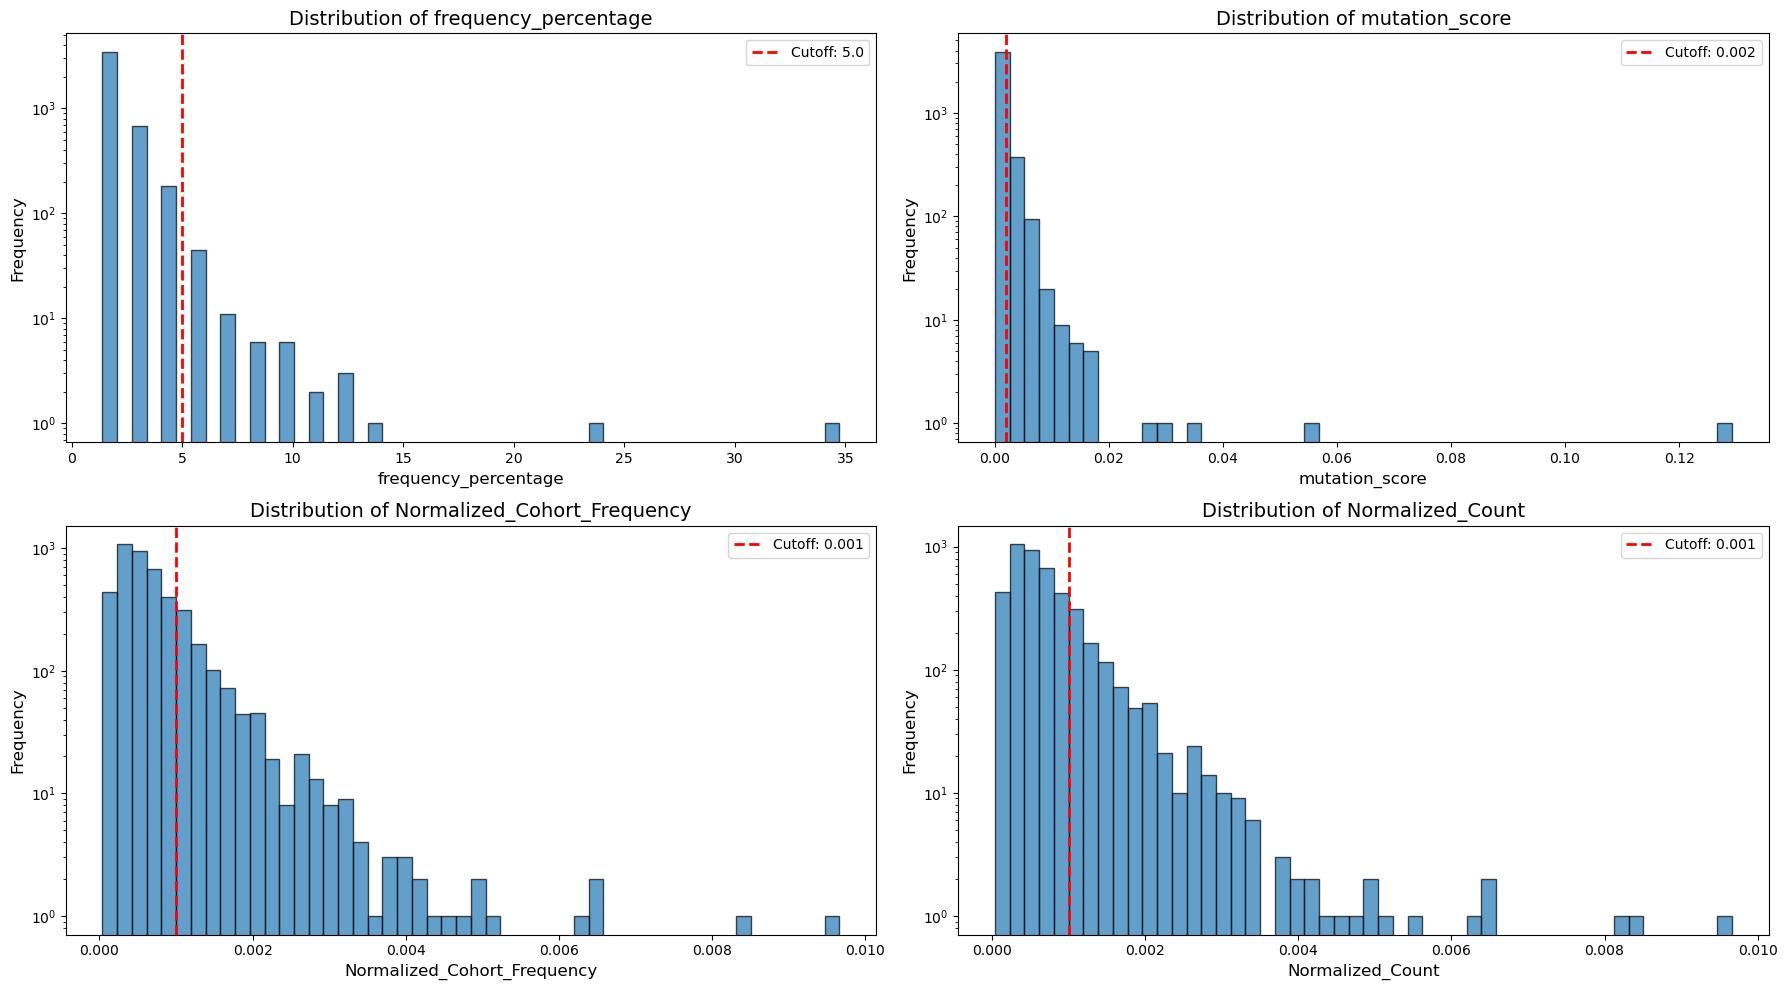

In [157]:
# Visualize with proposed cutoffs
plot_score_distribution_with_cutoff(hpv_pos_results, hpv_pos_cutoffs)

In [158]:
# Apply filtering to get top HPV+ genes
top_hpv_pos_genes = filter_top_genes(hpv_pos_results, hpv_pos_cutoffs)
print(f"\nTop {len(top_hpv_pos_genes)} HPV Positive genes after filtering:")
top_hpv_pos_genes

Genes passing all cutoffs: 6 out of 4388 total genes

Top 6 HPV Positive genes after filtering:


,Gene,Count,Cohort_Frequency,Normalized_Count,Normalized_Cohort_Frequency,P_Value,Adjusted_P_Value,Significant,Empirical_P_Value,Adjusted_Empirical_P_Value,frequency_percentage,mutation_score
78,PIK3CA,18,17,0.005473,0.005169,4.738394e-19,2.079207e-15,True,0.0001,0.036563,23.611111,0.129219
918,ZNF750,11,8,0.005071,0.003688,7.324983e-12,1.607101e-08,True,0.0001,0.036563,11.111111,0.056350
998,CYLD,8,8,0.002677,0.002677,6.578872e-07,9.622697e-04,True,0.0001,0.036563,11.111111,0.029749
2311,EP300,9,9,0.001243,0.001243,6.021135e-05,4.723959e-02,True,0.0001,0.036563,12.500000,0.015534
690,CCDC191,6,6,0.002083,0.002083,6.589348e-05,4.723959e-02,True,0.0001,0.036563,8.333333,0.017355
907,LRRC37B,6,5,0.001994,0.001662,8.343138e-05,4.723959e-02,True,0.0001,0.036563,6.944444,0.013847


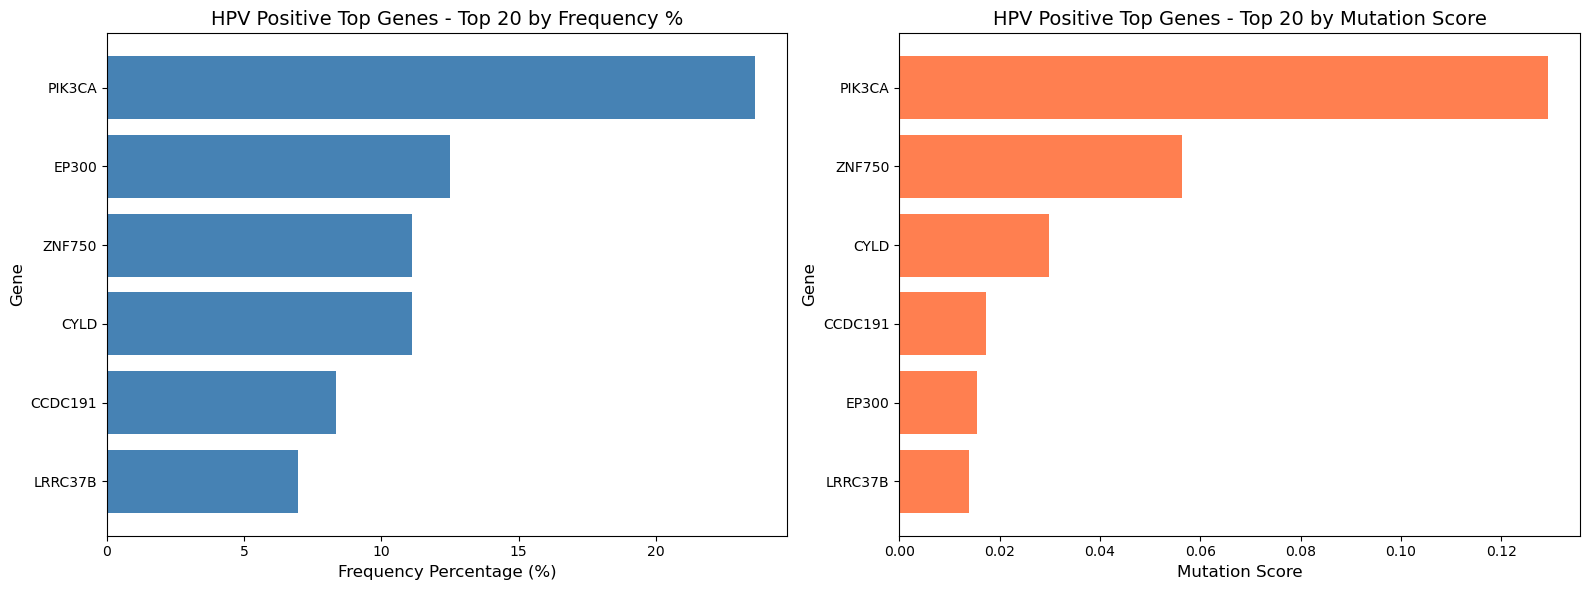

In [159]:
# Visualize top HPV+ genes
visualize_top_genes(top_hpv_pos_genes, title='HPV Positive Top Genes')

In [160]:
# top_hpv_results = hpv_pos_results[hpv_pos_results['Empirical_P_Value']<.05][hpv_pos_results['Adjusted_P_Value']<.05]
top_hpv_pos_genes.to_csv('Results/SOM results/HPV positive top genes.csv', index=False)

### HPV- 

In [161]:
hpv_negative_cases = somatic_mutation_download[~somatic_mutation_download['Case ID'].isin(hpv_positive_cases)]['Case ID']
print(len(set(hpv_negative_cases)))
hpv_negative_cases = list(set(hpv_negative_cases))

433


In [162]:
hpv_negative_case_somatic = somatic_mutation_download[somatic_mutation_download['Case ID'].isin(hpv_negative_cases)]

In [163]:
print(len(set(hpv_negative_case_somatic['Case ID'])))

433


In [164]:
print(len(set(hpv_negative_case_somatic['Hugo_Symbol'])))

16117


In [165]:
hpv_neg_results = run_mutation_analysis_pipeline(somatic_mutation_file, gtf_file, hpv_negative_cases)

Parsing GTF file: 4107087it [00:06, 629906.33it/s]


Total number of somatic mutations before filtering:  78588
Total number of somatic mutations after filtering for non-synonymous:  57516


Counting mutations: 100%|██████████| 57516/57516 [00:00<00:00, 5181151.37it/s]

Filtered out 357 genes not in reference genome (keeping 14246 genes)


In [166]:
hpv_neg_results.to_csv('Results/SOM results/HPV negative raw genes.csv', index=False)

In [167]:
hpv_neg_results

,Gene,Count,Cohort_Frequency,Normalized_Count,Normalized_Cohort_Frequency,P_Value,Adjusted_P_Value,Significant,Empirical_P_Value,Adjusted_Empirical_P_Value,frequency_percentage,mutation_score
26,TP53,405,345,0.234511,0.199768,0.000000e+00,0.000000e+00,True,0.000100,0.00596,79.676674,18.685034
1201,CDKN2A,105,101,0.106061,0.102020,3.536227e-135,2.518855e-131,True,0.000100,0.00596,23.325635,2.473931
993,CASP8,60,52,0.033670,0.029181,3.017299e-49,1.432815e-45,True,0.000100,0.00596,12.009238,0.404351
216,PIK3CA,69,67,0.020979,0.020371,2.482436e-43,8.841194e-40,True,0.000100,0.00596,15.473441,0.324618
221,FAT1,133,104,0.009495,0.007425,3.871006e-43,1.102927e-39,True,0.000100,0.00596,24.018476,0.228061
...,...,...,...,...,...,...,...,...,...,...,...,...
14598,RIC8A,1,1,0.000502,0.000502,9.863612e-01,1.000000e+00,False,0.960204,1.00000,0.230947,0.000116
14599,IFTAP,1,1,0.001323,0.001323,8.037382e-01,1.000000e+00,False,0.702130,1.00000,0.230947,0.000305
14600,AMHR2,1,1,0.000581,0.000581,9.753914e-01,1.000000e+00,False,0.934707,1.00000,0.230947,0.000134
14601,EMP3,1,1,0.001805,0.001805,6.967586e-01,1.000000e+00,False,0.577642,1.00000,0.230947,0.000417


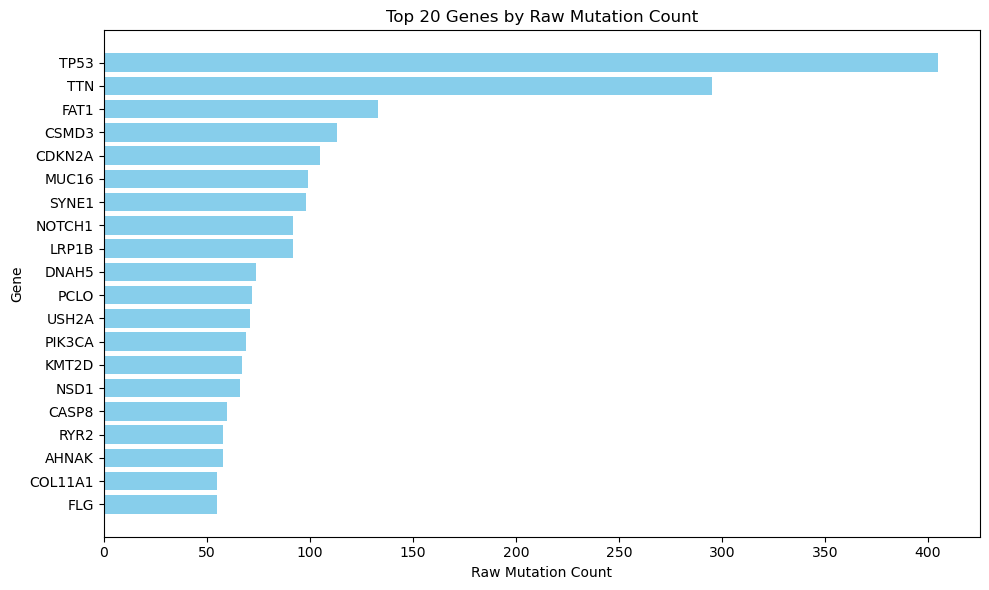

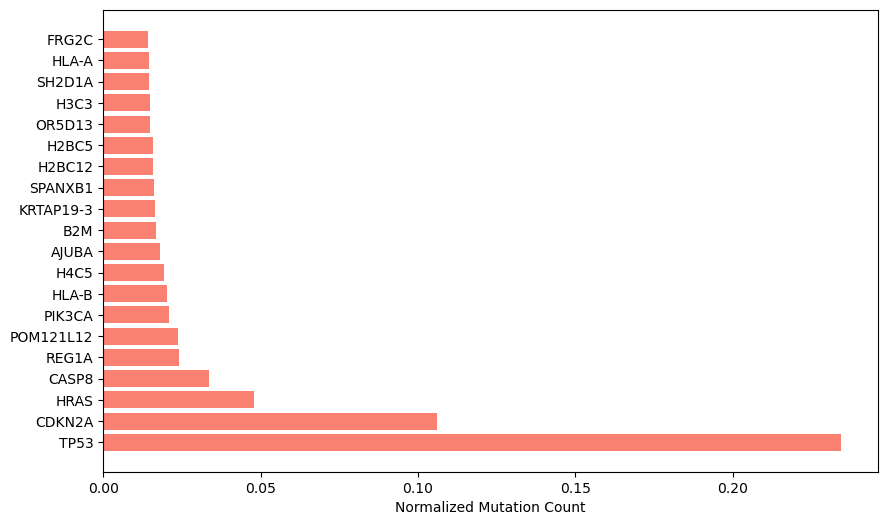

In [168]:
visualize_results(hpv_neg_results)

In [169]:
hpv_neg_results[hpv_neg_results['Adjusted_Empirical_P_Value']<.05][hpv_neg_results['Adjusted_P_Value']<.05]

/var/folders/5p/swntgnbj3fbfxkx02kt3fq980000gn/T/ipykernel_45902/1082000317.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hpv_neg_results[hpv_neg_results['Adjusted_Empirical_P_Value']<.05][hpv_neg_results['Adjusted_P_Value']<.05]


,Gene,Count,Cohort_Frequency,Normalized_Count,Normalized_Cohort_Frequency,P_Value,Adjusted_P_Value,Significant,Empirical_P_Value,Adjusted_Empirical_P_Value,frequency_percentage,mutation_score
26,TP53,405,345,0.234511,0.199768,0.000000e+00,0.000000e+00,True,0.0001,0.00596,79.676674,18.685034
1201,CDKN2A,105,101,0.106061,0.102020,3.536227e-135,2.518855e-131,True,0.0001,0.00596,23.325635,2.473931
993,CASP8,60,52,0.033670,0.029181,3.017299e-49,1.432815e-45,True,0.0001,0.00596,12.009238,0.404351
216,PIK3CA,69,67,0.020979,0.020371,2.482436e-43,8.841194e-40,True,0.0001,0.00596,15.473441,0.324618
221,FAT1,133,104,0.009495,0.007425,3.871006e-43,1.102927e-39,True,0.0001,0.00596,24.018476,0.228061
...,...,...,...,...,...,...,...,...,...,...,...,...
4029,UNC5C,16,16,0.005602,0.005602,6.598528e-04,4.771707e-02,True,0.0001,0.00596,3.695150,0.020701
4259,NLRP8,17,17,0.005407,0.005407,6.718725e-04,4.834088e-02,True,0.0001,0.00596,3.926097,0.021229
661,FAT3,49,38,0.003559,0.002760,6.965241e-04,4.946447e-02,True,0.0001,0.00596,8.775982,0.031236
2329,ZNF521,20,18,0.004957,0.004461,6.979052e-04,4.946447e-02,True,0.0001,0.00596,4.157044,0.020605


#### HPV Negative - Exploratory Analysis for Cutoff Determination

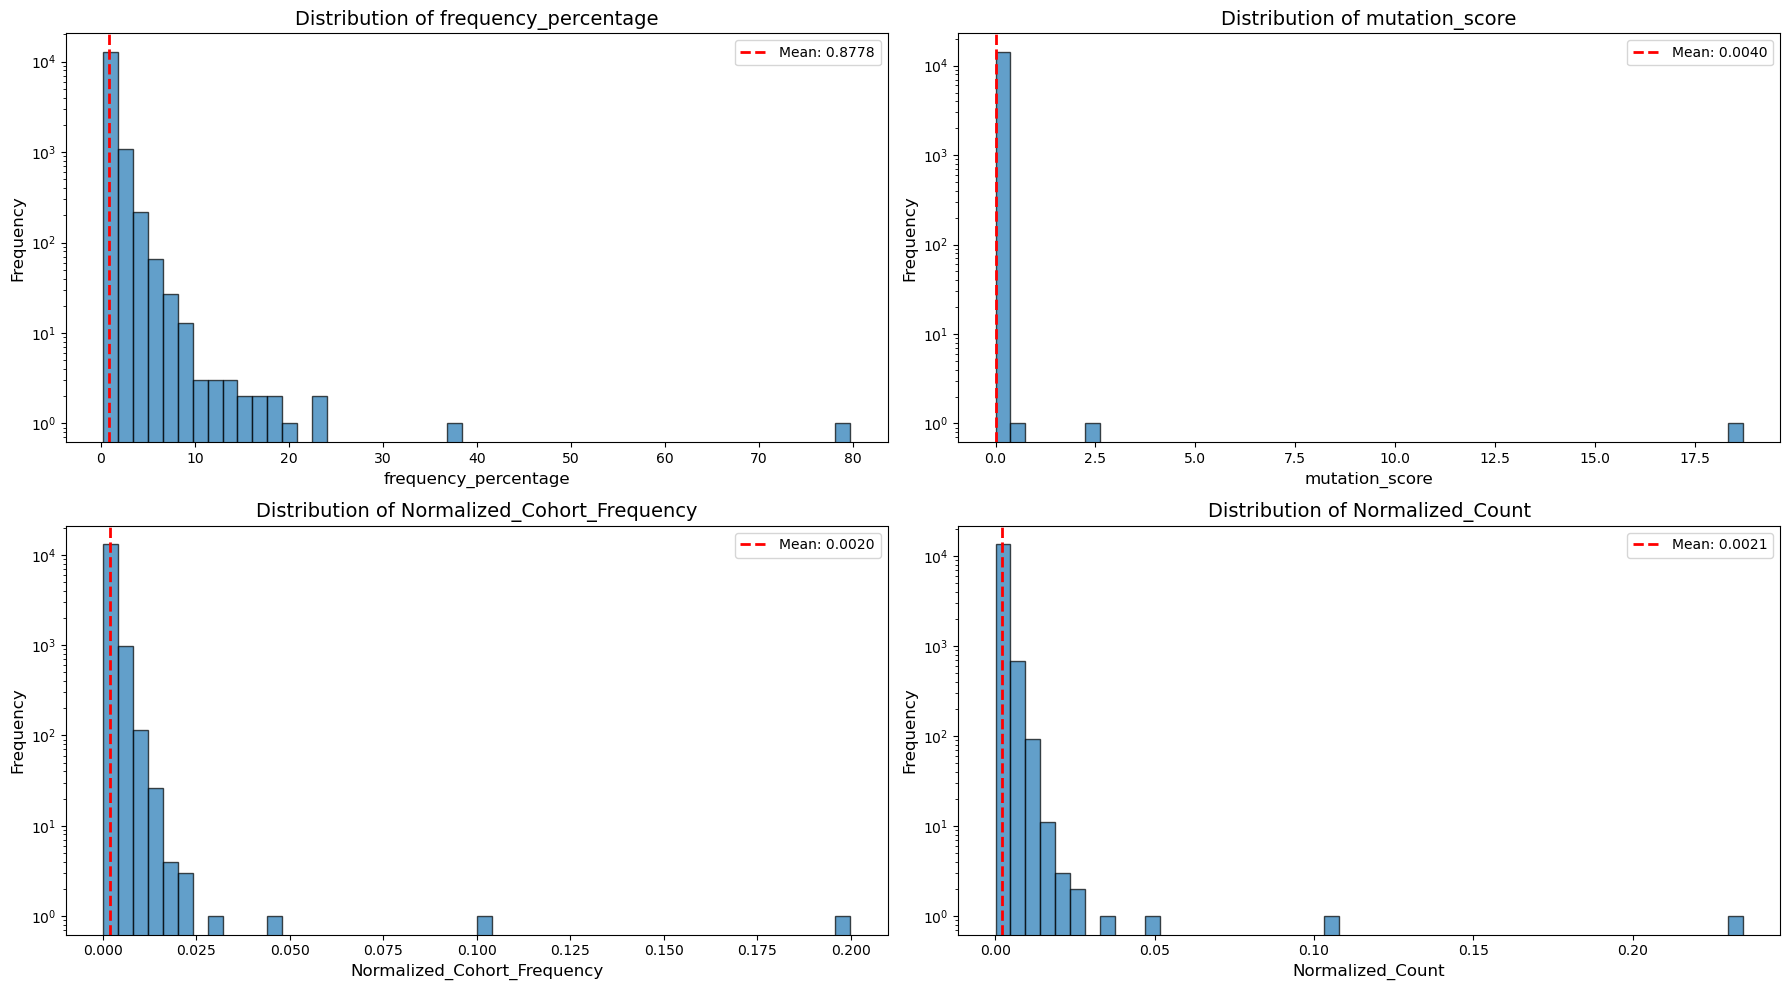

In [170]:
# Visualize score distributions to determine appropriate cutoffs
plot_score_distribution(hpv_neg_results)

In [176]:
# Define cutoffs based on exploratory analysis (will adjust after viewing distributions)
# Similar to CNV 02.2: HPV- can use slightly more stringent cutoffs due to larger sample size
hpv_neg_cutoffs = {
    'frequency_percentage': 1.7,
    'Adjusted_P_Value': 0.05,  # Standard significance threshold
    'Adjusted_Empirical_P_Value': 0.05,  # Empirical validation threshold
    'Normalized_Cohort_Frequency': .0045,
    'Normalized_Count': .0045,
    'mutation_score': .0045,
}

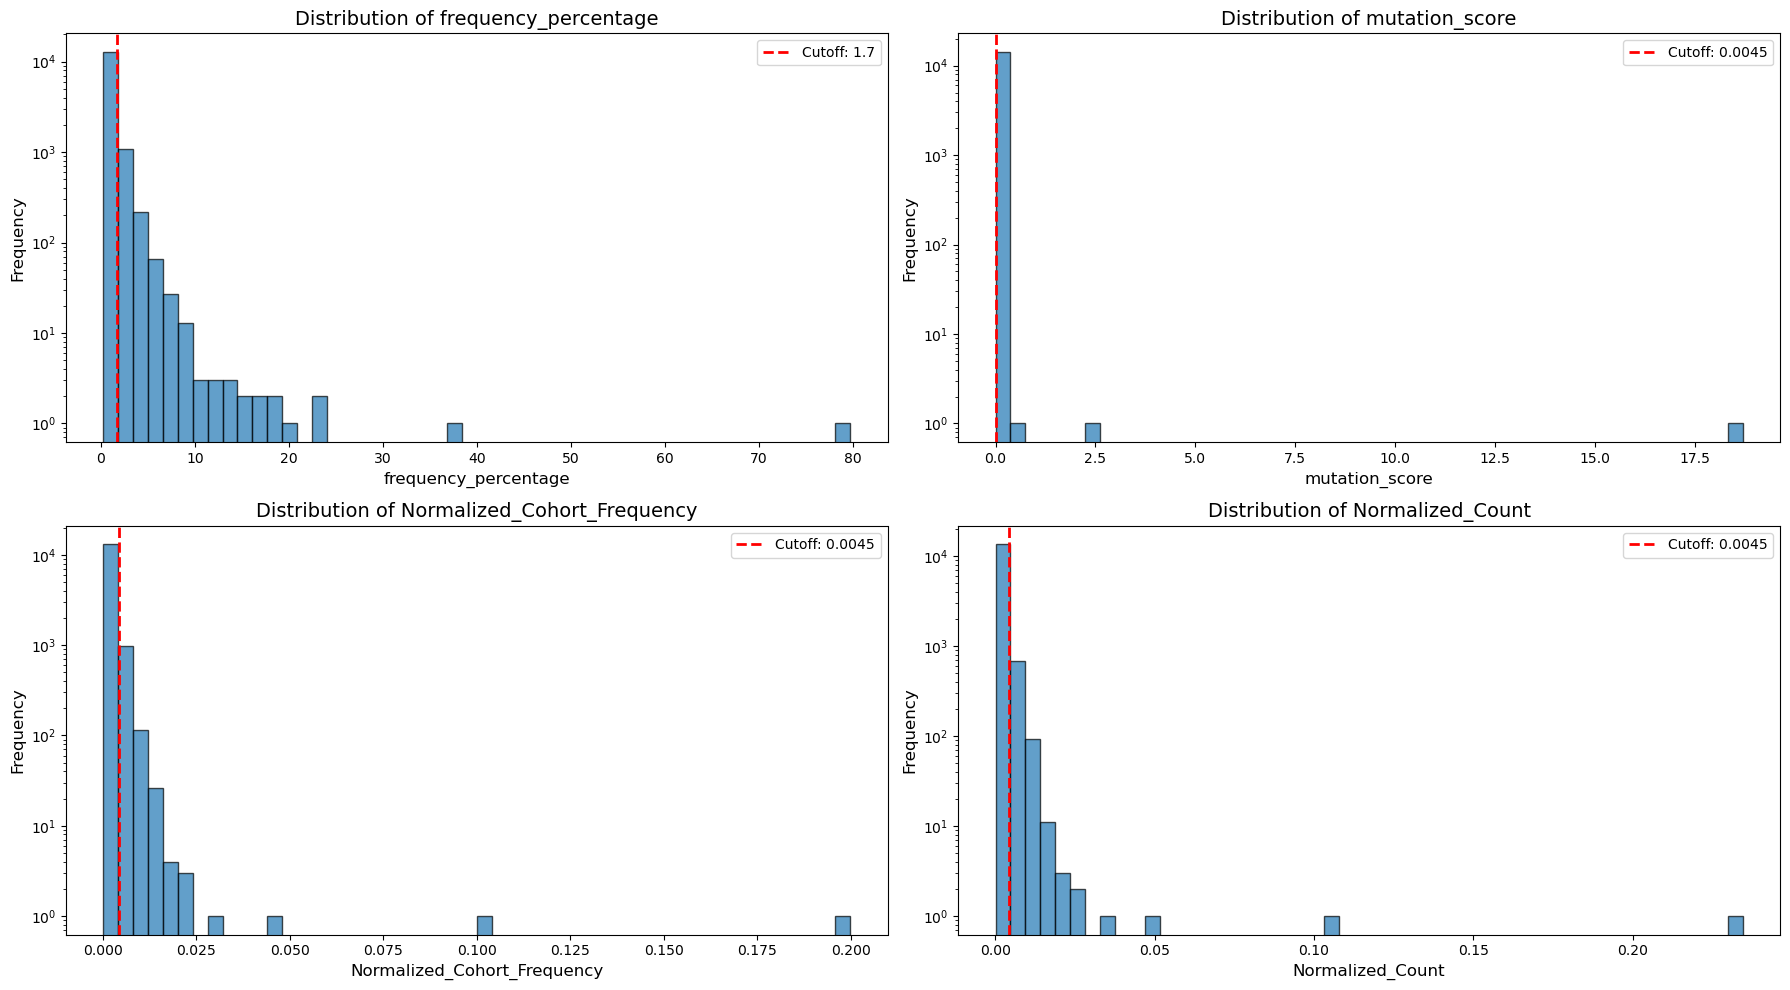

In [177]:
# Visualize with proposed cutoffs
plot_score_distribution_with_cutoff(hpv_neg_results, hpv_neg_cutoffs)

In [178]:
# Apply filtering to get top HPV- genes
top_hpv_neg_genes = filter_top_genes(hpv_neg_results, hpv_neg_cutoffs)
print(f"\nTop {len(top_hpv_neg_genes)} HPV Negative genes after filtering:")
top_hpv_neg_genes

Genes passing all cutoffs: 166 out of 14246 total genes

Top 166 HPV Negative genes after filtering:


,Gene,Count,Cohort_Frequency,Normalized_Count,Normalized_Cohort_Frequency,P_Value,Adjusted_P_Value,Significant,Empirical_P_Value,Adjusted_Empirical_P_Value,frequency_percentage,mutation_score
26,TP53,405,345,0.234511,0.199768,0.000000e+00,0.000000e+00,True,0.0001,0.005960,79.676674,18.685034
1201,CDKN2A,105,101,0.106061,0.102020,3.536227e-135,2.518855e-131,True,0.0001,0.005960,23.325635,2.473931
993,CASP8,60,52,0.033670,0.029181,3.017299e-49,1.432815e-45,True,0.0001,0.005960,12.009238,0.404351
216,PIK3CA,69,67,0.020979,0.020371,2.482436e-43,8.841194e-40,True,0.0001,0.005960,15.473441,0.324618
221,FAT1,133,104,0.009495,0.007425,3.871006e-43,1.102927e-39,True,0.0001,0.005960,24.018476,0.228061
...,...,...,...,...,...,...,...,...,...,...,...,...
7736,CLVS1,9,9,0.008475,0.008475,6.171865e-04,4.555668e-02,True,0.0002,0.009858,2.078522,0.017615
1652,KCTD8,11,10,0.007161,0.006510,6.506037e-04,4.728827e-02,True,0.0004,0.017162,2.309469,0.016539
4029,UNC5C,16,16,0.005602,0.005602,6.598528e-04,4.771707e-02,True,0.0001,0.005960,3.695150,0.020701
4259,NLRP8,17,17,0.005407,0.005407,6.718725e-04,4.834088e-02,True,0.0001,0.005960,3.926097,0.021229


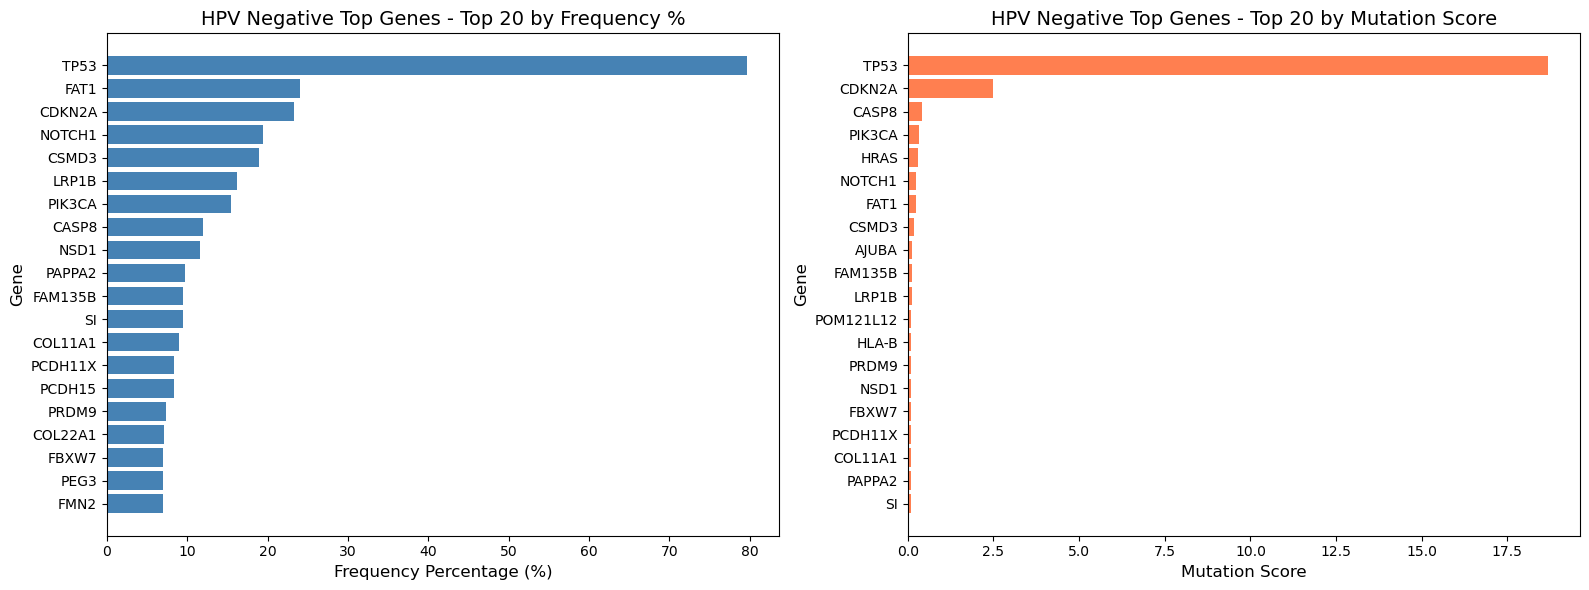

In [179]:
# Visualize top HPV- genes
visualize_top_genes(top_hpv_neg_genes, title='HPV Negative Top Genes')

In [180]:
# top_hpv_results = hpv_pos_results[hpv_pos_results['Empirical_P_Value']<.05][hpv_pos_results['Adjusted_P_Value']<.05]
top_hpv_neg_genes.to_csv('Results/SOM results/HPV negative top genes.csv', index=False)